# Demand Forecasting

## AI-Driven Public Transport Demand Planning
### Kharagpur–Kolkata Corridor

This notebook develops a passenger-demand forecasting model using the synthetic
90-day multimodal transportation dataset generated for the project.

### Objective

The objective is to estimate future passenger demand using historical demand
patterns and operational/calendar features.

The forecast generated here will later be used as an input to the transportation
capacity and fleet-allocation optimization model.

### Decision Pipeline

Historical Demand
↓
Feature Engineering
↓
Baseline Forecast
↓
Machine Learning Forecast
↓
Model Evaluation
↓
Future Demand Forecast
↓
Capacity Optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../data/synthetic/transport_demand_90days.csv",
    parse_dates=["date"]
)

df.head()

,date,origin,destination,mode,passengers,festival,weekend
0,2025-08-01,Kharagpur,Midnapore,Rail,12298,0,0
1,2025-08-01,Kharagpur,Midnapore,Bus,7867,0,0
2,2025-08-01,Midnapore,Uluberia,Rail,14453,0,0
3,2025-08-01,Midnapore,Uluberia,Bus,7688,0,0
4,2025-08-01,Uluberia,Howrah,Rail,12848,0,0


In [3]:
print("Dataset shape:", df.shape)
print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (720, 7)

Date range:
2025-08-01 00:00:00 to 2025-10-29 00:00:00

Columns:
['date', 'origin', 'destination', 'mode', 'passengers', 'festival', 'weekend']

Missing values:
date           0
origin         0
destination    0
mode           0
passengers     0
festival       0
weekend        0
dtype: int64


In [4]:
# Create time-based features

df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

# Display the new features
df.head()

,date,origin,destination,mode,passengers,festival,weekend,day_of_week,day_of_month,month,week_of_year
0,2025-08-01,Kharagpur,Midnapore,Rail,12298,0,0,4,1,8,31
1,2025-08-01,Kharagpur,Midnapore,Bus,7867,0,0,4,1,8,31
2,2025-08-01,Midnapore,Uluberia,Rail,14453,0,0,4,1,8,31
3,2025-08-01,Midnapore,Uluberia,Bus,7688,0,0,4,1,8,31
4,2025-08-01,Uluberia,Howrah,Rail,12848,0,0,4,1,8,31


In [5]:
# Create a unique corridor identifier

df["route"] = (
    df["origin"] + "_" +
    df["destination"] + "_" +
    df["mode"]
)

df[["date", "route", "passengers", "festival", "weekend"]].head(10)

,date,route,passengers,festival,weekend
0,2025-08-01,Kharagpur_Midnapore_Rail,12298,0,0
1,2025-08-01,Kharagpur_Midnapore_Bus,7867,0,0
2,2025-08-01,Midnapore_Uluberia_Rail,14453,0,0
3,2025-08-01,Midnapore_Uluberia_Bus,7688,0,0
4,2025-08-01,Uluberia_Howrah_Rail,12848,0,0
5,2025-08-01,Uluberia_Howrah_Bus,7775,0,0
6,2025-08-01,Howrah_Kolkata_Rail,16184,0,0
7,2025-08-01,Howrah_Kolkata_Bus,7099,0,0
8,2025-08-02,Kharagpur_Midnapore_Rail,21093,1,1
9,2025-08-02,Kharagpur_Midnapore_Bus,15338,1,1


In [6]:
df = df.sort_values(["route", "date"]).reset_index(drop=True)

df.head()

,date,origin,destination,mode,passengers,festival,weekend,day_of_week,day_of_month,month,week_of_year,route
0,2025-08-01,Howrah,Kolkata,Bus,7099,0,0,4,1,8,31,Howrah_Kolkata_Bus
1,2025-08-02,Howrah,Kolkata,Bus,10911,1,1,5,2,8,31,Howrah_Kolkata_Bus
2,2025-08-03,Howrah,Kolkata,Bus,4580,0,1,6,3,8,31,Howrah_Kolkata_Bus
3,2025-08-04,Howrah,Kolkata,Bus,7945,0,0,0,4,8,32,Howrah_Kolkata_Bus
4,2025-08-05,Howrah,Kolkata,Bus,6654,0,0,1,5,8,32,Howrah_Kolkata_Bus


In [7]:
# Historical demand features

df["lag_1"] = df.groupby("route")["passengers"].shift(1)
df["lag_7"] = df.groupby("route")["passengers"].shift(7)

# Rolling averages using only historical observations
df["rolling_7"] = (
    df.groupby("route")["passengers"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df[[
    "date",
    "route",
    "passengers",
    "lag_1",
    "lag_7",
    "rolling_7"
]].head(15)

,date,route,passengers,lag_1,lag_7,rolling_7
0,2025-08-01,Howrah_Kolkata_Bus,7099,NaN,NaN,NaN
1,2025-08-02,Howrah_Kolkata_Bus,10911,7099.0,NaN,NaN
2,2025-08-03,Howrah_Kolkata_Bus,4580,10911.0,NaN,NaN
3,2025-08-04,Howrah_Kolkata_Bus,7945,4580.0,NaN,NaN
4,2025-08-05,Howrah_Kolkata_Bus,6654,7945.0,NaN,NaN
5,2025-08-06,Howrah_Kolkata_Bus,7325,6654.0,NaN,NaN
6,2025-08-07,Howrah_Kolkata_Bus,7226,7325.0,NaN,NaN
7,2025-08-08,Howrah_Kolkata_Bus,5567,7226.0,7099.0,7391.428571
8,2025-08-09,Howrah_Kolkata_Bus,6545,5567.0,10911.0,7172.571429
9,2025-08-10,Howrah_Kolkata_Bus,4207,6545.0,4580.0,6548.857143


In [8]:
# Remove observations where historical features are not yet available

df_model = df.dropna(
    subset=["lag_1", "lag_7", "rolling_7"]
).copy()

print("Original observations:", len(df))
print("Model observations:", len(df_model))
print("Rows removed:", len(df) - len(df_model))

Original observations: 720
Model observations: 664
Rows removed: 56


In [9]:
df_model[
    [
        "date",
        "route",
        "passengers",
        "festival",
        "weekend",
        "day_of_week",
        "lag_1",
        "lag_7",
        "rolling_7"
    ]
].head(10)

,date,route,passengers,festival,weekend,day_of_week,lag_1,lag_7,rolling_7
7,2025-08-08,Howrah_Kolkata_Bus,5567,0,0,4,7226.0,7099.0,7391.428571
8,2025-08-09,Howrah_Kolkata_Bus,6545,0,1,5,5567.0,10911.0,7172.571429
9,2025-08-10,Howrah_Kolkata_Bus,4207,0,1,6,6545.0,4580.0,6548.857143
10,2025-08-11,Howrah_Kolkata_Bus,6756,0,0,0,4207.0,7945.0,6495.571429
11,2025-08-12,Howrah_Kolkata_Bus,5358,0,0,1,6756.0,6654.0,6325.714286
12,2025-08-13,Howrah_Kolkata_Bus,5874,0,0,2,5358.0,7325.0,6140.571429
13,2025-08-14,Howrah_Kolkata_Bus,6479,0,0,3,5874.0,7226.0,5933.285714
14,2025-08-15,Howrah_Kolkata_Bus,12756,1,0,4,6479.0,5567.0,5826.571429
15,2025-08-16,Howrah_Kolkata_Bus,5150,0,1,5,12756.0,6545.0,6853.571429
16,2025-08-17,Howrah_Kolkata_Bus,6553,0,1,6,5150.0,4207.0,6654.285714


In [10]:
# Determine chronological cutoff

cutoff_date = df_model["date"].quantile(0.80)

train = df_model[df_model["date"] <= cutoff_date].copy()
test = df_model[df_model["date"] > cutoff_date].copy()

print("Cutoff date:", cutoff_date)
print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

print("\nTraining observations:", len(train))
print("Testing observations:", len(test))

Cutoff date: 2025-10-13 00:00:00

Training period:
2025-08-08 00:00:00 to 2025-10-13 00:00:00

Testing period:
2025-10-14 00:00:00 to 2025-10-29 00:00:00

Training observations: 536
Testing observations: 128


In [11]:
# Naïve forecasting baseline
# Prediction = previous day's actual demand

test["naive_prediction"] = test["lag_1"]

# Calculate evaluation metrics
naive_mae = mean_absolute_error(
    test["passengers"],
    test["naive_prediction"]
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test["passengers"],
        test["naive_prediction"]
    )
)

naive_r2 = r2_score(
    test["passengers"],
    test["naive_prediction"]
)

print("Naïve Forecast Performance")
print("-" * 35)
print(f"MAE  : {naive_mae:,.2f} passengers")
print(f"RMSE : {naive_rmse:,.2f} passengers")
print(f"R²   : {naive_r2:.4f}")

Naïve Forecast Performance
-----------------------------------
MAE  : 1,942.23 passengers
RMSE : 3,412.45 passengers
R²   : 0.2625


In [12]:
# ============================================
# 4. RANDOM FOREST DEMAND FORECASTING
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features used for forecasting
features = [
    "festival",
    "weekend",
    "day_of_week",
    "lag_1",
    "lag_7",
    "rolling_7"
]

target = "passengers"

# Prepare train and test data
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

# --------------------------------------------
# Train Random Forest
# --------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# --------------------------------------------
# Predictions
# --------------------------------------------

y_pred_rf = rf_model.predict(X_test)

# --------------------------------------------
# Evaluation
# --------------------------------------------

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance")
print("-----------------------------------")
print(f"MAE  : {mae_rf:,.2f} passengers")
print(f"RMSE : {rmse_rf:,.2f} passengers")
print(f"R²   : {r2_rf:.4f}")

Training observations: 536
Testing observations: 128

Random Forest Performance
-----------------------------------
MAE  : 771.93 passengers
RMSE : 1,012.91 passengers
R²   : 0.9350


## The Random Forest model substantially outperformed the naïve previous-day demand baseline on the chronological test set, reducing MAE by approximately 60% and RMSE by approximately 70%. The model explained approximately 93.5% of the variance in the held-out test set.

In [13]:
# ============================================
# ACTUAL VS RANDOM FOREST PREDICTIONS
# ============================================

results = test[
    ["date", "route", "passengers"]
].copy()

results["rf_prediction"] = y_pred_rf

results.head(10)

,date,route,passengers,rf_prediction
74,2025-10-14,Howrah_Kolkata_Bus,6794,6226.866755
75,2025-10-15,Howrah_Kolkata_Bus,5529,6682.681936
76,2025-10-16,Howrah_Kolkata_Bus,6601,6513.236012
77,2025-10-17,Howrah_Kolkata_Bus,7549,6657.328605
78,2025-10-18,Howrah_Kolkata_Bus,6539,5557.296802
79,2025-10-19,Howrah_Kolkata_Bus,4666,5991.835972
80,2025-10-20,Howrah_Kolkata_Bus,11624,11866.844887
81,2025-10-21,Howrah_Kolkata_Bus,6546,6315.657562
82,2025-10-22,Howrah_Kolkata_Bus,6076,7110.323912
83,2025-10-23,Howrah_Kolkata_Bus,4883,6562.071181


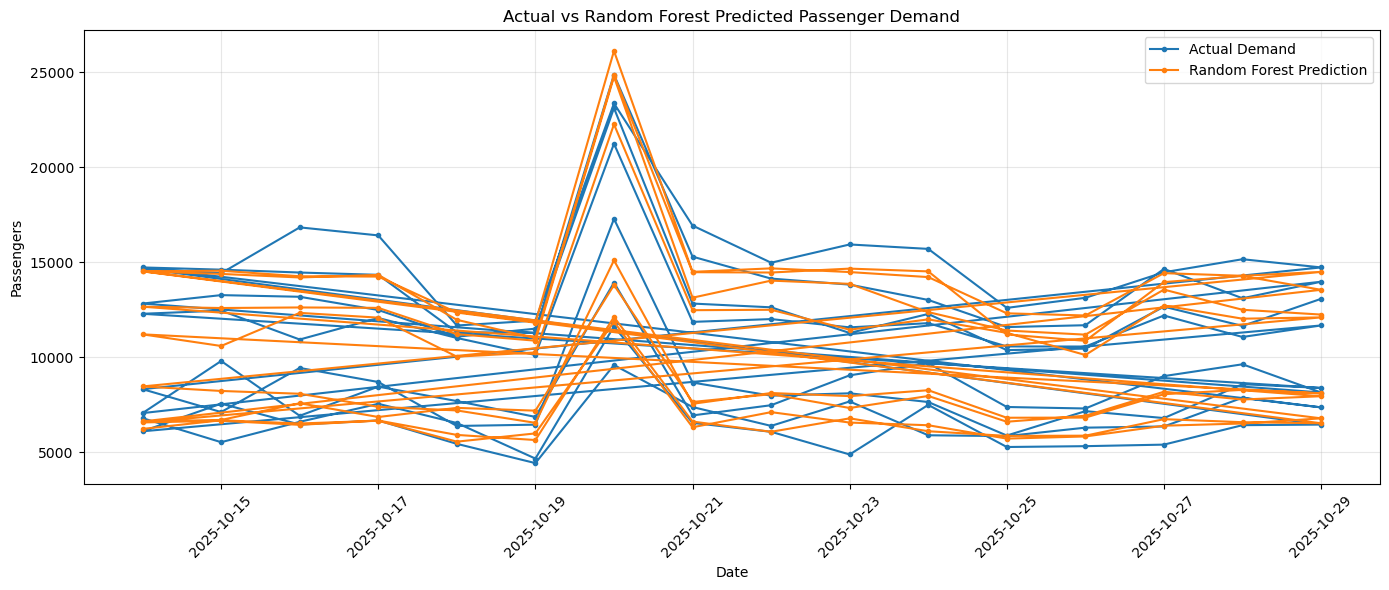

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(
    results["date"],
    results["passengers"],
    marker="o",
    markersize=3,
    label="Actual Demand"
)

plt.plot(
    results["date"],
    results["rf_prediction"],
    marker="o",
    markersize=3,
    label="Random Forest Prediction"
)

plt.title("Actual vs Random Forest Predicted Passenger Demand")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
5,rolling_7,0.594778
0,festival,0.328771
4,lag_7,0.053901
3,lag_1,0.009339
2,day_of_week,0.008510
1,weekend,0.004701


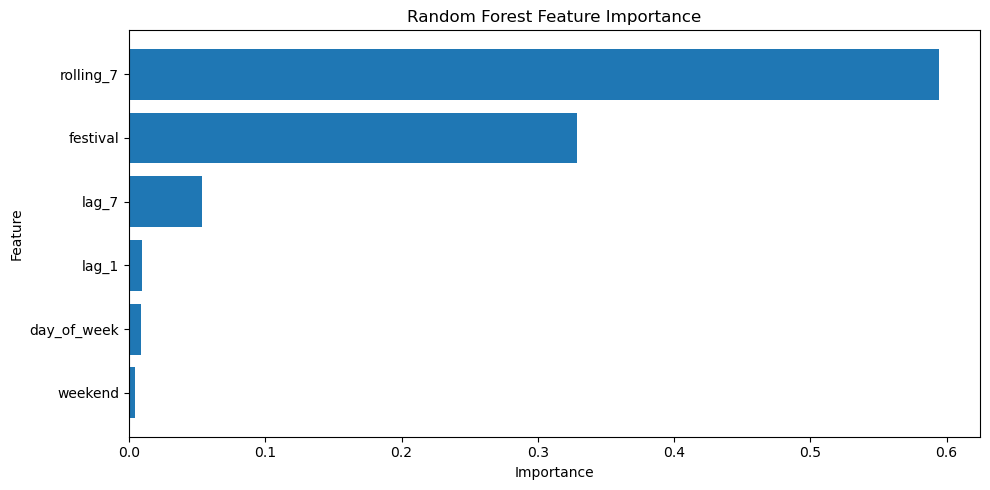

In [16]:
plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
# ============================================
# 5. FORECAST ERROR ANALYSIS
# ============================================

results["error"] = results["passengers"] - results["rf_prediction"]
results["absolute_error"] = results["error"].abs()
results["percentage_error"] = (
    results["absolute_error"] / results["passengers"]
) * 100

print("Forecast Error Statistics")
print("-----------------------------------")
print(f"Mean Error           : {results['error'].mean():,.2f}")
print(f"Mean Absolute Error  : {results['absolute_error'].mean():,.2f}")
print(f"Mean Percentage Error: {results['percentage_error'].mean():.2f}%")

print("\nLargest Forecast Errors")
print("-----------------------------------")

results.sort_values(
    "absolute_error",
    ascending=False
)[
    ["date", "route", "passengers", "rf_prediction", "error", "percentage_error"]
].head(10)

Forecast Error Statistics
-----------------------------------
Mean Error           : 70.99
Mean Absolute Error  : 771.93
Mean Percentage Error: 8.08%

Largest Forecast Errors
-----------------------------------


,date,route,passengers,rf_prediction,error,percentage_error
615,2025-10-15,Uluberia_Howrah_Bus,9802,6699.938243,3102.061757,31.647233
170,2025-10-20,Howrah_Kolkata_Rail,23359,26119.390580,-2760.390580,11.817246
713,2025-10-23,Uluberia_Howrah_Rail,11277,13861.717357,-2584.717357,22.920257
166,2025-10-16,Howrah_Kolkata_Rail,16834,14261.524663,2572.475337,15.281426
440,2025-10-20,Midnapore_Uluberia_Bus,9590,12116.710981,-2526.710981,26.347351
171,2025-10-21,Howrah_Kolkata_Rail,16930,14493.407362,2436.592638,14.392160
260,2025-10-20,Kharagpur_Midnapore_Bus,17284,15101.063125,2182.936875,12.629813
167,2025-10-17,Howrah_Kolkata_Rail,16412,14245.438789,2166.561211,13.201080
345,2025-10-15,Kharagpur_Midnapore_Rail,12454,10592.287512,1861.712488,14.948711
628,2025-10-28,Uluberia_Howrah_Bus,9629,7774.866032,1854.133968,19.255727


In [18]:
# ============================================
# 6. MODEL COMPARISON
# ============================================

comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Random Forest"
    ],
    "MAE": [
        1942.23,
        mae_rf
    ],
    "RMSE": [
        3412.45,
        rmse_rf
    ],
    "R2": [
        0.2625,
        r2_rf
    ]
})

comparison["MAE Improvement (%)"] = [
    0,
    (1942.23 - mae_rf) / 1942.23 * 100
]

comparison["RMSE Improvement (%)"] = [
    0,
    (3412.45 - rmse_rf) / 3412.45 * 100
]

comparison

,Model,MAE,RMSE,R2,MAE Improvement (%),RMSE Improvement (%)
0,Naive Baseline,1942.230000,3412.450000,0.262500,0.000000,0.000000
1,Random Forest,771.931795,1012.905817,0.935021,60.255387,70.317343
